# Trabajo final:

**Enlace de obtención del dataset:** https://www.openml.org/search?type=data&sort=runs&id=45279&status=active

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ajustes de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

Explicación de cada variable:


- `pkSeqID`	            Row Identifier
- `sbytes`	            Source-to-destination byte count
- `Stime` 	            Record start time
- `dbytes`	            Destination-to-source byte count
- `flgs`	            Flow state flags seen in trans- actions
- `rate`  	            Total packets per second in transaction
- `flgs number`	        Numerical representation of feature flags
- `srate`	            Source-to-destination packets per second
- `Proto`	            Textual representation of transaction protocols present in network flow
- `drate`	            Destination-to-source packets per second
- `proto_number`	    Numerical representation of feature proto
- `TnBPSrcIP`	        Total Number of bytes per source IP
- `saddr`               Source IP address
- `TnBPDstIP`	        Total Number of bytes per Destination IP
- `sport`	            Source port number
- `TnP_PSrcIP`	        Total Number of packets per source IP
- `daddr`	            Destination IP address
- `TnP_PDstIP`	        Total Number of packets per Destination IP
- `dport`	            Destination port number
- `TnP_PerProto`	    Total Number of packets per protocol
- `pkts`	            Total count of packets in transaction
- `TnP_Per_Dport`	    Total Number of packets per dport
- `bytes`	            Total number of bytes in transaction
- `AR_P_Proto_P_SrcIP`	Average rate per protocol per Source IP. (calculated by pkts/dur)
- `state`	            Transaction state
- `AR_P_Proto_P_DstIP`	Average rate per protocol per Destination IP
- `state_number`    	Numerical representation of feature state
- `ltime`           	Record last time
- `N_IN_Conn_P_SrcIP`	Number of inbound connections per source IP
- `seq`	                Argus sequence number
- `N_IN_Conn_P_DstIP`	Number of inbound connections per destination IP
- `dur`	                Record total duration
- `AR_P_Proto_P_Sport`	Average rate per protocol per sport
- `mean`            	Average duration of aggregated records
- `AR_P_Proto_P_Dport`	Average rate per protocol per dport
- `stddev`          	Standard deviation of aggregated records
- `Pkts_P_State_P_Protocol_P_DestIP`	Number of packets grouped by state of flows and protocols per destination IP
- `sum`            	    Total duration of aggregated records
- `Pkts_P_State_P_Protocol_P_SrcIP` 	Number of packets grouped by state of flows and protocols per source IP
- `min`             	Minimum duration of aggregated records
- `attack`          	Class label: 0 for Normal traffic, 1 for Attack Traffic
- `max`             	Maximum duration of aggregated records
- `category`        	Traffic category
- `spkts`           	Source-to-destination packet count
- `subcategory`     	Traffic subcategory
- `dpkts`           	Destination-to-source packet count

## Preprocesado:

In [2]:
dtypes = {
    'stime': 'float32',
    'flgs': 'category',
    'flgs_number': 'UInt8',
    'proto': 'category',
    'proto_number': 'UInt8',
    'saddr': 'category',
    'sport': 'Int32',
    'daddr': 'category',
    'dport': 'Int32',
    'pkts': 'UInt32',
    'bytes': 'UInt32',
    'state': 'category',
    'state_number': 'UInt8',
    'ltime': 'float32',
    'seq': 'UInt32',
    'dur': 'float32',
    'mean': 'float32',
    'stddev': 'float32',
    'sum': 'float32',
    'min': 'float32',
    'max': 'float32',
    'spkts': 'UInt16',
    'dpkts': 'UInt16',
    'sbytes': 'UInt32',
    'dbytes': 'UInt32',
    'rate': 'float32',
    'srate': 'float32',
    'drate': 'float32',
    'TnBPSrcIP': 'UInt32',
    'TnBPDstIP': 'UInt32',
    'TnP_PSrcIP': 'UInt32',
    'TnP_PDstIP': 'UInt32',
    'TnP_PerProto': 'UInt32',
    'TnP_Per_Dport': 'UInt32',
    'AR_P_Proto_P_SrcIP': 'float32',
    'AR_P_Proto_P_DstIP': 'float32',
    'N_IN_Conn_P_DstIP': 'UInt8',
    'N_IN_Conn_P_SrcIP': 'UInt8',
    'AR_P_Proto_P_Sport': 'float32',
    'AR_P_Proto_P_Dport': 'float32',
    'Pkts_P_State_P_Protocol_P_DestIP': 'UInt32',
    'Pkts_P_State_P_Protocol_P_SrcIP': 'UInt32',
    'device': 'category',
    'attack': 'category',
    'category': 'category',
    'subcategory': 'category'
    }

In [3]:
df = pd.read_csv("datos_ciber.csv", index_col='pkSeqID', dtype=dtypes)

In [5]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
Index: 3668522 entries, 1000001 to 3668522
Data columns (total 46 columns):
 #   Column                            Dtype   
---  ------                            -----   
 0   stime                             float32 
 1   flgs                              category
 2   flgs_number                       UInt8   
 3   proto                             category
 4   proto_number                      UInt8   
 5   saddr                             category
 6   sport                             Int32   
 7   daddr                             category
 8   dport                             Int32   
 9   pkts                              UInt32  
 10  bytes                             UInt32  
 11  state                             category
 12  state_number                      UInt8   
 13  ltime                             float32 
 14  seq                               UInt32  
 15  dur                               float32 
 16  mean                        

In [6]:
df.sort_values(by=['dpkts'])

,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,pkts,bytes,state,state_number,ltime,seq,dur,mean,stddev,sum,min,max,spkts,dpkts,sbytes,dbytes,rate,srate,drate,TnBPSrcIP,TnBPDstIP,TnP_PSrcIP,TnP_PDstIP,TnP_PerProto,TnP_Per_Dport,AR_P_Proto_P_SrcIP,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,device,attack,category,subcategory
pkSeqID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1000001,1.528085e+09,e,1,udp,3,192.168.100.148,37153,192.168.100.6,80,8,480,INT,4,1.528085e+09,120567,25.001644,3.565624,0.023105,14.262497,3.539353,3.601970,8,0,480,0,0.279982,0.279982,0.000000,48000,48000,800,800,800,800,0.319943,0.319943,100,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
2344698,1.528096e+09,e s,2,tcp,1,192.168.100.148,25582,192.168.100.3,80,5,770,REQ,3,1.528096e+09,169158,12.835121,2.149763,1.525840,6.449290,0.000000,3.386419,5,0,770,0,0.311645,0.311645,0.000000,77000,77000,500,500,500,500,0.389536,0.389536,100,100,0.389556,0.389536,500,500,external,Malicious,DDoS,TCP
2344699,1.528096e+09,e s,2,tcp,1,192.168.100.148,25583,192.168.100.3,80,5,770,REQ,3,1.528096e+09,169159,12.835121,2.149763,1.525840,6.449288,0.000000,3.386418,5,0,770,0,0.311645,0.311645,0.000000,77000,77000,500,500,500,500,0.389536,0.389536,100,100,0.389556,0.389536,500,500,external,Malicious,DDoS,TCP
2344700,1.528096e+09,e s,2,tcp,1,192.168.100.148,25584,192.168.100.3,80,5,770,REQ,3,1.528096e+09,169160,12.835121,2.149762,1.525839,6.449287,0.000000,3.386417,5,0,770,0,0.311645,0.311645,0.000000,77000,77000,500,500,500,500,0.389536,0.389536,100,100,0.389556,0.389536,500,500,external,Malicious,DDoS,TCP
2344701,1.528096e+09,e s,2,tcp,1,192.168.100.148,25585,192.168.100.3,80,5,770,REQ,3,1.528096e+09,169161,12.835121,2.149762,1.525839,6.449287,0.000000,3.386417,5,0,770,0,0.311645,0.311645,0.000000,77000,77000,500,500,500,500,0.389533,0.389533,100,100,0.389556,0.389533,500,500,external,Malicious,DDoS,TCP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3576926,1.526344e+09,e,1,udp,3,192.168.100.46,3456,192.168.100.5,80,59452,59114121,CON,2,1.526346e+09,2,1685.706909,4.947584,0.231615,1662.388062,0.710969,4.999863,29726,29726,30347258,28766863,35.267696,17.633553,17.633553,220390664,220390784,225519,225521,200009,244425,26.667999,26.667999,7,6,35.557301,26.667999,112544,112544,external,Benign,Normal,Normal
3577165,1.526350e+09,e &,7,tcp,1,192.168.100.55,8080,192.168.100.3,80,69595,69797982,CON,2,1.526352e+09,1,1745.653564,4.966639,0.008544,1728.390259,4.950418,4.995234,34798,34797,35616240,34181742,39.867016,19.933508,19.932936,69797982,92682875,69595,121862,140717,220979,39.867599,19.450800,7,1,39.867599,22.258200,102714,69595,external,Benign,Normal,Normal
3577168,1.526350e+09,e,1,udp,3,192.168.100.46,3456,192.168.100.5,80,69600,69187620,CON,2,1.526352e+09,4,1745.758057,4.967142,0.007519,1728.565430,4.950445,4.997839,34800,34800,35020980,34166640,39.867496,19.933460,19.933460,134442585,134442585,139201,139201,123687,220979,29.901100,29.901100,3,3,39.868099,29.901100,69600,69600,external,Benign,Normal,Normal


### Tratamiento de datos faltantes:

In [7]:
# Contamos la cantidad de datos faltanes por variable 
df.isna().sum()

stime                               0
flgs                                0
flgs_number                         0
proto                               0
proto_number                        0
saddr                               0
sport                               0
daddr                               0
dport                               0
pkts                                0
bytes                               0
state                               0
state_number                        0
ltime                               0
seq                                 0
dur                                 0
mean                                0
stddev                              0
sum                                 0
min                                 0
max                                 0
spkts                               0
dpkts                               0
sbytes                              0
dbytes                              0
rate                                0
srate       

Vemos que no ninguna de las variables cuenta con datos faltanes.

### Tratamiento de outliers:

In [8]:
# Solo columnas numéricas
df_num = df.select_dtypes(include=np.number)

# Media y std vectorizados
mean = df_num.mean()
std = df_num.std()

outliers_z = ((df_num - mean).abs() > 3 * std)
outliers_ordenados_z = outliers_z.sum().sort_values(ascending=False)

print(f"{'-'*5} CANTIDAD DE OUTLIERS POR COLUMNA (USANDO Z-SCORE) {'-'*5}")
print(outliers_ordenados_z)

----- CANTIDAD DE OUTLIERS POR COLUMNA (USANDO Z-SCORE) -----
flgs_number                         128953
N_IN_Conn_P_DstIP                   121130
stime                                91638
ltime                                91638
dport                                28081
AR_P_Proto_P_DstIP                   25683
N_IN_Conn_P_SrcIP                    17061
AR_P_Proto_P_SrcIP                   14248
rate                                  7178
AR_P_Proto_P_Sport                    6932
AR_P_Proto_P_Dport                    6712
state_number                          2586
drate                                 2005
dur                                   1539
srate                                  451
TnP_PerProto                           355
Pkts_P_State_P_Protocol_P_DestIP       141
TnP_PSrcIP                             105
TnBPSrcIP                               63
TnP_Per_Dport                           51
TnP_PDstIP                              49
Pkts_P_State_P_Protocol_P_SrcIP    

In [9]:
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((df_num < (Q1 - 1.5 * IQR)) | (df_num > (Q3 + 1.5 * IQR)))
outliers_ordenados_iqr = outliers_iqr.sum().sort_values(ascending=False)

print(f"{'-'*5} CANTIDAD DE OUTLIERS POR COLUMNA (USANDO IQR) {'-'*5}")
print(outliers_ordenados_iqr)

----- CANTIDAD DE OUTLIERS POR COLUMNA (USANDO IQR) -----
dpkts                               860828
dbytes                              860828
N_IN_Conn_P_DstIP                   798222
state_number                        784141
spkts                               443504
rate                                343654
AR_P_Proto_P_SrcIP                  294145
AR_P_Proto_P_Dport                  279903
srate                               274902
drate                               270243
AR_P_Proto_P_Sport                  261815
AR_P_Proto_P_DstIP                  256209
TnP_PDstIP                          197258
TnP_PSrcIP                          166345
pkts                                140466
flgs_number                         129769
N_IN_Conn_P_SrcIP                   110683
dport                                94947
TnP_PerProto                         91754
stime                                91638
ltime                                91638
TnP_Per_Dport                        91

In [10]:
outliers_ambos = outliers_z & outliers_iqr
outliers_ordenados_ambos = outliers_ambos.sum().sort_values(ascending=False)

print(f"{'-'*5} CANTIDAD DE OUTLIERS POR COLUMNA (DETECTADOS POR AMBOS MÉTODOS) {'-'*5}")
print(outliers_ordenados_ambos)

----- CANTIDAD DE OUTLIERS POR COLUMNA (DETECTADOS POR AMBOS MÉTODOS) -----
flgs_number                         128953
N_IN_Conn_P_DstIP                   121130
stime                                91638
ltime                                91638
dport                                28081
AR_P_Proto_P_DstIP                   25683
N_IN_Conn_P_SrcIP                    17061
AR_P_Proto_P_SrcIP                   14248
rate                                  7178
AR_P_Proto_P_Sport                    6932
AR_P_Proto_P_Dport                    6712
state_number                          2586
drate                                 2005
dur                                   1539
srate                                  451
TnP_PerProto                           355
Pkts_P_State_P_Protocol_P_DestIP       141
TnP_PSrcIP                             105
TnBPSrcIP                               63
TnP_Per_Dport                           51
TnP_PDstIP                              49
Pkts_P_State_P_Protoc

#### Eliminación de los outliers fuera de rango:

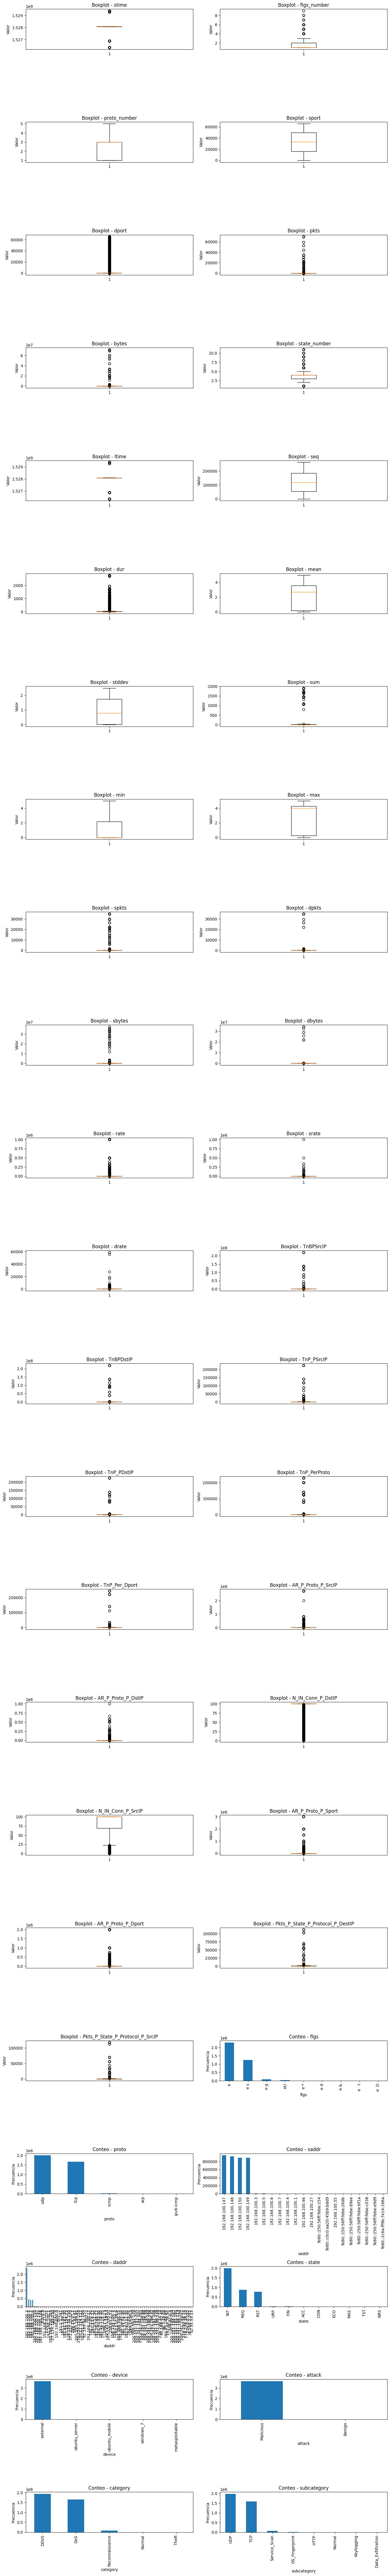

In [11]:
import math

# Columnas
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='category').columns

all_cols = list(numeric_cols) + list(categorical_cols)

# Definir grid automáticamente
n_cols = 2  # número de columnas en la grilla
n_rows = math.ceil(len(all_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
axes = axes.flatten()  # para iterar fácil

for i, col in enumerate(all_cols):
    ax = axes[i]
    
    if col in numeric_cols:
        ax.boxplot(df[col].dropna())
        ax.set_title(f'Boxplot - {col}')
        ax.set_ylabel('Valor')
        
    else:
        df[col].value_counts().plot(kind='bar', ax=ax)
        ax.set_title(f'Conteo - {col}')
        ax.set_ylabel('Frecuencia')
        ax.set_xlabel(col)

# Eliminar subplots vacíos si sobran
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Winsorización de los outliers correspondientes:

In [12]:
from scipy.stats.mstats import winsorize

# Definir las columnas a winsorizar y sus límites de percentil

def winsorize_df(df: pd.DataFrame, columns: list[str], lower=0.05, upper=0.05):
    df_out = df.copy()
    
    for col in columns:
        if col in df_out.columns:
            # Convertir a float (evita problemas con pandas dtypes raros)
            x = df_out[col].astype('float64')
            
            # Aplicar winsorización
            x_w = winsorize(x, limits=(lower, upper))
            
            # Guardar de vuelta (como float)
            df_out[col] = x_w.astype('float64')
    
    return df_out

cols_winsor = [
    'stime', 'ltime', 'dport', 'rate', 'srate', 'drate',
    'AR_P_Proto_P_DstIP', 'N_IN_Conn_P_DstIP',
    'AR_P_Proto_P_SrcIP', 'AR_P_Proto_P_Sport', 'AR_P_Proto_P_Dport'
]

df = winsorize_df(df, cols_winsor, lower=0.05, upper=0.05)

In [13]:
df

,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,pkts,bytes,state,state_number,ltime,seq,dur,mean,stddev,sum,min,max,spkts,dpkts,sbytes,dbytes,rate,srate,drate,TnBPSrcIP,TnBPDstIP,TnP_PSrcIP,TnP_PDstIP,TnP_PerProto,TnP_Per_Dport,AR_P_Proto_P_SrcIP,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,device,attack,category,subcategory
pkSeqID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1000001,1.528085e+09,e,1,udp,3,192.168.100.148,37153,192.168.100.6,80.0,8,480,INT,4,1.528085e+09,120567,25.001644,3.565624,0.023105,14.262497,3.539353,3.601970,8,0,480,0,0.279982,0.279982,0.000000,48000,48000,800,800,800,800,0.319943,0.319943,100.0,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
1000002,1.528085e+09,e,1,udp,3,192.168.100.148,37154,192.168.100.6,80.0,8,480,INT,4,1.528085e+09,120568,25.001644,3.565624,0.023096,14.262495,3.539352,3.601970,8,0,480,0,0.279982,0.279982,0.000000,48000,48000,800,800,800,800,0.319943,0.319943,100.0,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
1000003,1.528085e+09,e,1,udp,3,192.168.100.148,37155,192.168.100.6,80.0,8,480,INT,4,1.528085e+09,120569,25.001644,3.565624,0.023096,14.262495,3.539353,3.601970,8,0,480,0,0.279982,0.279982,0.000000,48000,48000,800,800,800,800,0.319943,0.319943,100.0,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
1000004,1.528085e+09,e,1,udp,3,192.168.100.148,37156,192.168.100.6,80.0,8,480,INT,4,1.528085e+09,120570,25.001644,3.565624,0.023059,14.262497,3.539353,3.601970,8,0,480,0,0.279982,0.279982,0.000000,48000,48000,800,800,800,800,0.319943,0.319943,100.0,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
1000005,1.528085e+09,e,1,udp,3,192.168.100.148,37157,192.168.100.6,80.0,8,480,INT,4,1.528085e+09,120571,25.001644,3.565624,0.023096,14.262495,3.539353,3.601969,8,0,480,0,0.279982,0.279982,0.000000,48000,48000,800,800,800,800,0.319943,0.319943,100.0,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3668518,1.528099e+09,e,1,tcp,1,192.168.100.150,35064,192.168.100.3,80.0,6,434,RST,1,1.528099e+09,81,0.013165,0.013165,0.000000,0.013165,0.013165,0.013165,3,3,228,206,1.025271,1.020217,0.040295,79240,79240,471,471,475,471,9.889330,9.889330,46.0,19,10.055000,9.889330,30,30,external,Malicious,Theft,Keylogging
3668519,1.528099e+09,e,1,tcp,1,192.168.100.150,35066,192.168.100.3,80.0,6,434,RST,1,1.528099e+09,82,0.000574,0.000574,0.000000,0.000574,0.000574,0.000574,3,3,228,206,1.025271,1.020217,0.040295,79240,79240,471,471,475,471,9.889330,9.889330,46.0,19,10.055000,9.889330,30,30,external,Malicious,Theft,Keylogging
3668520,1.528099e+09,e,1,tcp,1,192.168.100.150,35070,192.168.100.3,80.0,31,5472,FIN,6,1.528099e+09,84,2.874302,2.874302,0.000000,2.874302,2.874302,2.874302,14,17,1802,3670,1.025271,1.020217,0.040295,79240,79240,471,471,475,471,9.889330,9.889330,46.0,19,10.055000,9.889330,441,441,external,Malicious,Theft,Keylogging


In [14]:
# Solo columnas numéricas
df_num = df.select_dtypes(include=np.number)

# Media y std vectorizados
mean = df_num.mean()
std = df_num.std()

outliers_z = ((df_num - mean).abs() > 3 * std)
outliers_ordenados_z = outliers_z.sum().sort_values(ascending=False)

print(f"{'-'*5} CANTIDAD DE OUTLIERS POR COLUMNA (USANDO Z-SCORE) {'-'*5}")
print(outliers_ordenados_z)

----- CANTIDAD DE OUTLIERS POR COLUMNA (USANDO Z-SCORE) -----
drate                               255655
AR_P_Proto_P_DstIP                  207566
AR_P_Proto_P_SrcIP                  203900
AR_P_Proto_P_Dport                  197474
AR_P_Proto_P_Sport                  192011
N_IN_Conn_P_DstIP                   190793
flgs_number                         128953
N_IN_Conn_P_SrcIP                    17061
state_number                          2586
dur                                   1539
TnP_PerProto                           355
Pkts_P_State_P_Protocol_P_DestIP       141
TnP_PSrcIP                             105
TnBPSrcIP                               63
TnP_Per_Dport                           51
Pkts_P_State_P_Protocol_P_SrcIP         49
TnP_PDstIP                              49
pkts                                    44
bytes                                   44
spkts                                   44
sbytes                                  44
TnBPDstIP                          

### Eliminación de variables sin utilidad:

In [15]:
# Revisamos si los valores de bytes son la suma de sbytes y dbytes
print((df["bytes"] == (df["sbytes"] + df["dbytes"])).all())

True


In [16]:
# Revisamos si los valores de pkts son la suma de spkts y dpkts
print((df["pkts"] == (df["spkts"] + df["dpkts"])).all())

False


Obtenemos el resultado de `False` lo que nos indica que no todos los valores de pkts son la suma de spkts y dpkts. Veamos ahora, cuántos valores cumplen "pkts" $\neq$ "spkts" + "dpkts".

In [17]:
print(f"La cantidad de valores distintos es {(df["pkts"] != 
                                              (df["spkts"] + df["dpkts"])).sum()}, de los {len(df)} valores totales.")

La cantidad de valores distintos es 4, de los 3668522 valores totales.


In [18]:
print(f"La cantidad de valores distintos es {(df["rate"] != 
                                              (df["srate"] + df["drate"])).sum()}, de los {len(df)} valores totales.")

La cantidad de valores distintos es 1095589, de los 3668522 valores totales.


Podemos observar que:

* `bytes = sbytes + dbytes`, por tanto podemos quedarnos solo con la variable `bytes`.
* `pkts = spkts + dpkts` (menos en 4 columnas), por tanto podemos quedarnos solo con la variable `pkts`.
* `rate = srate + drate`, por tanto podemos quedarnos solo con la variable `rate`.
* `dur = ltime - stime`, por tanto podemos quedarnos solo con la variable `dur`.

In [19]:
# Eiliminamos las columnas `sbytes`, `dbytes`, `spkts` y `dpkts`
df = df.drop(columns=["sbytes", "dbytes", "pkts", "spkts", "srate", "drate", "ltime", "stime"])

### Separación entre variable objetivo y resto de variables:

In [20]:
X = df.drop(columns=["category"])
# Variable objetivo
y = df["category"]

print(f"Contamos con {len(X.columns)} variables distintas de la variable objetivo: Category.")

Contamos con 37 variables distintas de la variable objetivo: Category.


### Separación en train y test:

In [21]:
from sklearn.model_selection import train_test_split

# Separación en train y test:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

### Transformación:

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
import joblib

# Separar columnas
num_cols = X.select_dtypes(include=[np.number]).columns.to_list()
cat_cols = X.select_dtypes(include=['category', 'object']).columns.to_list()

# Preprocesadores
numeric_transformer = MinMaxScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])


X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)


# Guardar preprocessor
joblib.dump(preprocessor, "preprocessor.pkl")

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


['preprocessor.pkl']

In [37]:
print(f"Contamos tras la transformación con {X_train_processed.shape[1]} variables.")

Contamos tras la transformación con 160 variables.


### Análisis exploratorio:

#### Descripción de las variables:

In [38]:
df_X_train = pd.DataFrame(X_train_processed)
df_X_train.describe(include="all").round(2)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159
count,2934817.00,2934817.00,2934817.00,2934817.0,2934817.0,2934817.00,2934817.00,2934817.00,2934817.00,2934817.00,2934817.00,2934817.00,2934817.00,2934817.0,2934817.00,2934817.0,2934817.0,2934817.0,2934817.0,2934817.00,2934817.0,2934817.00,2934817.00,2934817.00,2934817.00,2934817.00,2934817.00,2934817.00,2934817.00,2934817.0,2934817.0,2934817.0,2934817.00,2934817.00,2934817.00,2934817.00,2934817.00,2934817.00,2934817.0,2934817.00,2934817.00,2934817.00,2934817.00,2934817.00,2934817.00,2934817.0,2934817.00,2934817.0,2934817.0,2934817.00,2934817.0,2934817.00,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.00,2934817.00,2934817.00,2934817.00,2934817.0,2934817.0,2934817.00,2934817.0,2934817.00,2934817.0,2934817.00,2934817.00,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.0,2934817.00,2934817.0,2934817.00,2934817.00,2934817.0,2934817.0,2934817.00,2934817.00,2934817.0,2934817.00,2934817.0,2934817.00,2934817.00,2934817.00,2934817.00,2934817.00,2934817.0,2934817.00,2934817.00,2934817.00,2934817.00,2934817.00
mean,0.06,0.27,0.50,0.0,0.0,0.21,0.46,0.01,0.45,0.36,0.00,0.20,0.60,0.0,0.34,0.0,0.0,0.0,0.0,0.00,0.0,0.08,0.08,0.87,0.82,0.08,0.08,0.01,0.00,0.0,0.0,0.0,0.00,0.00,0.03,0.34,0.01,0.00,0.0,0.45,0.54,0.26,0.25,0.24,0.24,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.65,0.0,0.12,0.0,0.11,0.11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.54,0.0,0.0,0.24,0.21,0.0,0.00,0.0,0.00,0.00,0.00,1.00,0.00,0.0,0.00,0.00,0.02,0.43,0.54
std,0.11,0.25,0.29,0.0,0.0,0.12,0.29,0.01,0.30,0.32,0.00,0.30,0.37,0.0,0.29,0.0,0.0,0.0,0.0,0.01,0.0,0.22,0.23,0.28,0.25,0.22,0.22,0.00,0.00,0.0,0.0,0.0,0.01,0.01,0.16,0.47,0.10,0.05,0.0,0.50,0.50,0.44,0.43,0.43,0.43,0.0,0.05,0.0,0.0,0.04,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.03,0.03,0.03,0.03,0.0,0.0,0.48,0.0,0.33,0.0,0.32,0.32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.04,0.50,0.0,0.0,0.43,0.41,0.0,0.05,0.0,0.04,0.05,0.01,0.01,0.03,0.0,0.01,0.07,0.14,0.50,0.50
min,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.

In [39]:
df_X_train.head(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159
0,0.125,0.0,0.026382,0.0,0.000009,0.0,0.379019,0.014999,0.213625,0.516222,0.001669,0.000000,0.575585,0.000029,0.051872,0.000333,0.000333,0.002638,0.002638,0.002605,0.002434,0.002153,0.001090,1.000000,1.000000,0.004304,0.001193,0.004505,0.004299,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.000,0.5,0.397537,0.0,0.000006,0.3,0.223274,0.005103,0.676280,0.376597,0.005283,0.409484,0.808236,0.000000,0.444428,0.000198,0.000225,0.003224,0.003663,0.003617,0.003379,0.035301,0.032644,1.000000,0.909091,0.046636,0.039141,0.007339,0.006164,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.000,0.5,0.032852,0.0,0.000005,0.3,0.794402,0.004469,0.555533,0.783811,0.004340,0.000000,0.830874,0.000000,0.433384,0.000076,0.000190,0.001237,0.003100,0.003061,0.002860,0.035261,0.031446,1.000000,0.393939,0.046585,0.037700,0.006211,0.002366,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.125,0.0,0.907852,0.0,0.000008,0.2,0.149387,0.011994,0.167870,0.473701,0.001311,0.000000,0.501785,0.000000,0.020409,0.000274,0.000279,0.001734,0.001769,0.001747,0.001632,0.000354,0.000000,1.000000,0.979798,0.001893,0.000000,0.003545,0.003315,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.000,0.5,0.515244,0.0,0.000004,0.3,0.259390,0.011370,0.173668,0.693052,0.002261,0.000000,0.865193,0.000000,0.092093,0.000189,0.000189,0.003082,0.003082,0.003043,0.002843,0.008236,0.006610,1.000000,1.000000,0.008933,0.007832,0.006175,0.005893,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

#### Estudio de la variable objetivo:

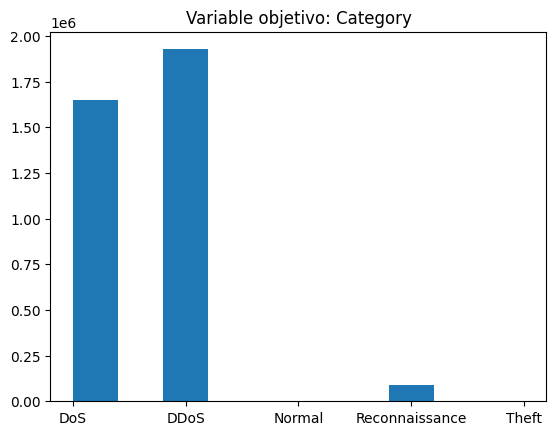

In [40]:
plt.hist(y)
plt.title("Variable objetivo: Category")
plt.show()

Tenemos solamente 5 categorías distintas:

In [41]:
# Valores únicos de la variable objetivo y
y.unique()

['DoS', 'DDoS', 'Normal', 'Reconnaissance', 'Theft']
Categories (5, str): ['DoS', 'DDoS', 'Normal', 'Reconnaissance', 'Theft']

Distribución de cada categoría de la variable `Category`:

In [42]:
total_observaciones = len(df)

for category, count in y.value_counts().items():
    print(f"{category}: {count}")

print()

for category, count in y.value_counts().items():
    print(f"{category}: {round(count/total_observaciones, 5)*100}%.")

DDoS: 1926624
DoS: 1650260
Reconnaissance: 91082
Normal: 477
Theft: 79

DDoS: 52.518%.
DoS: 44.984%.
Reconnaissance: 2.483%.
Normal: 0.013%.
Theft: 0.002%.


Observamos que existe un gran desbalanceo de clases, más del $97\%$ de los datos solamente pertenecen a las dos clases `DDoS` y `DoS`, mientras que las otras 3 clases cuentan con un $3\%$ aproximademente de los datos.

#### Análisis de la correlación y colinealidad entre variables:

In [43]:
import seaborn as sns

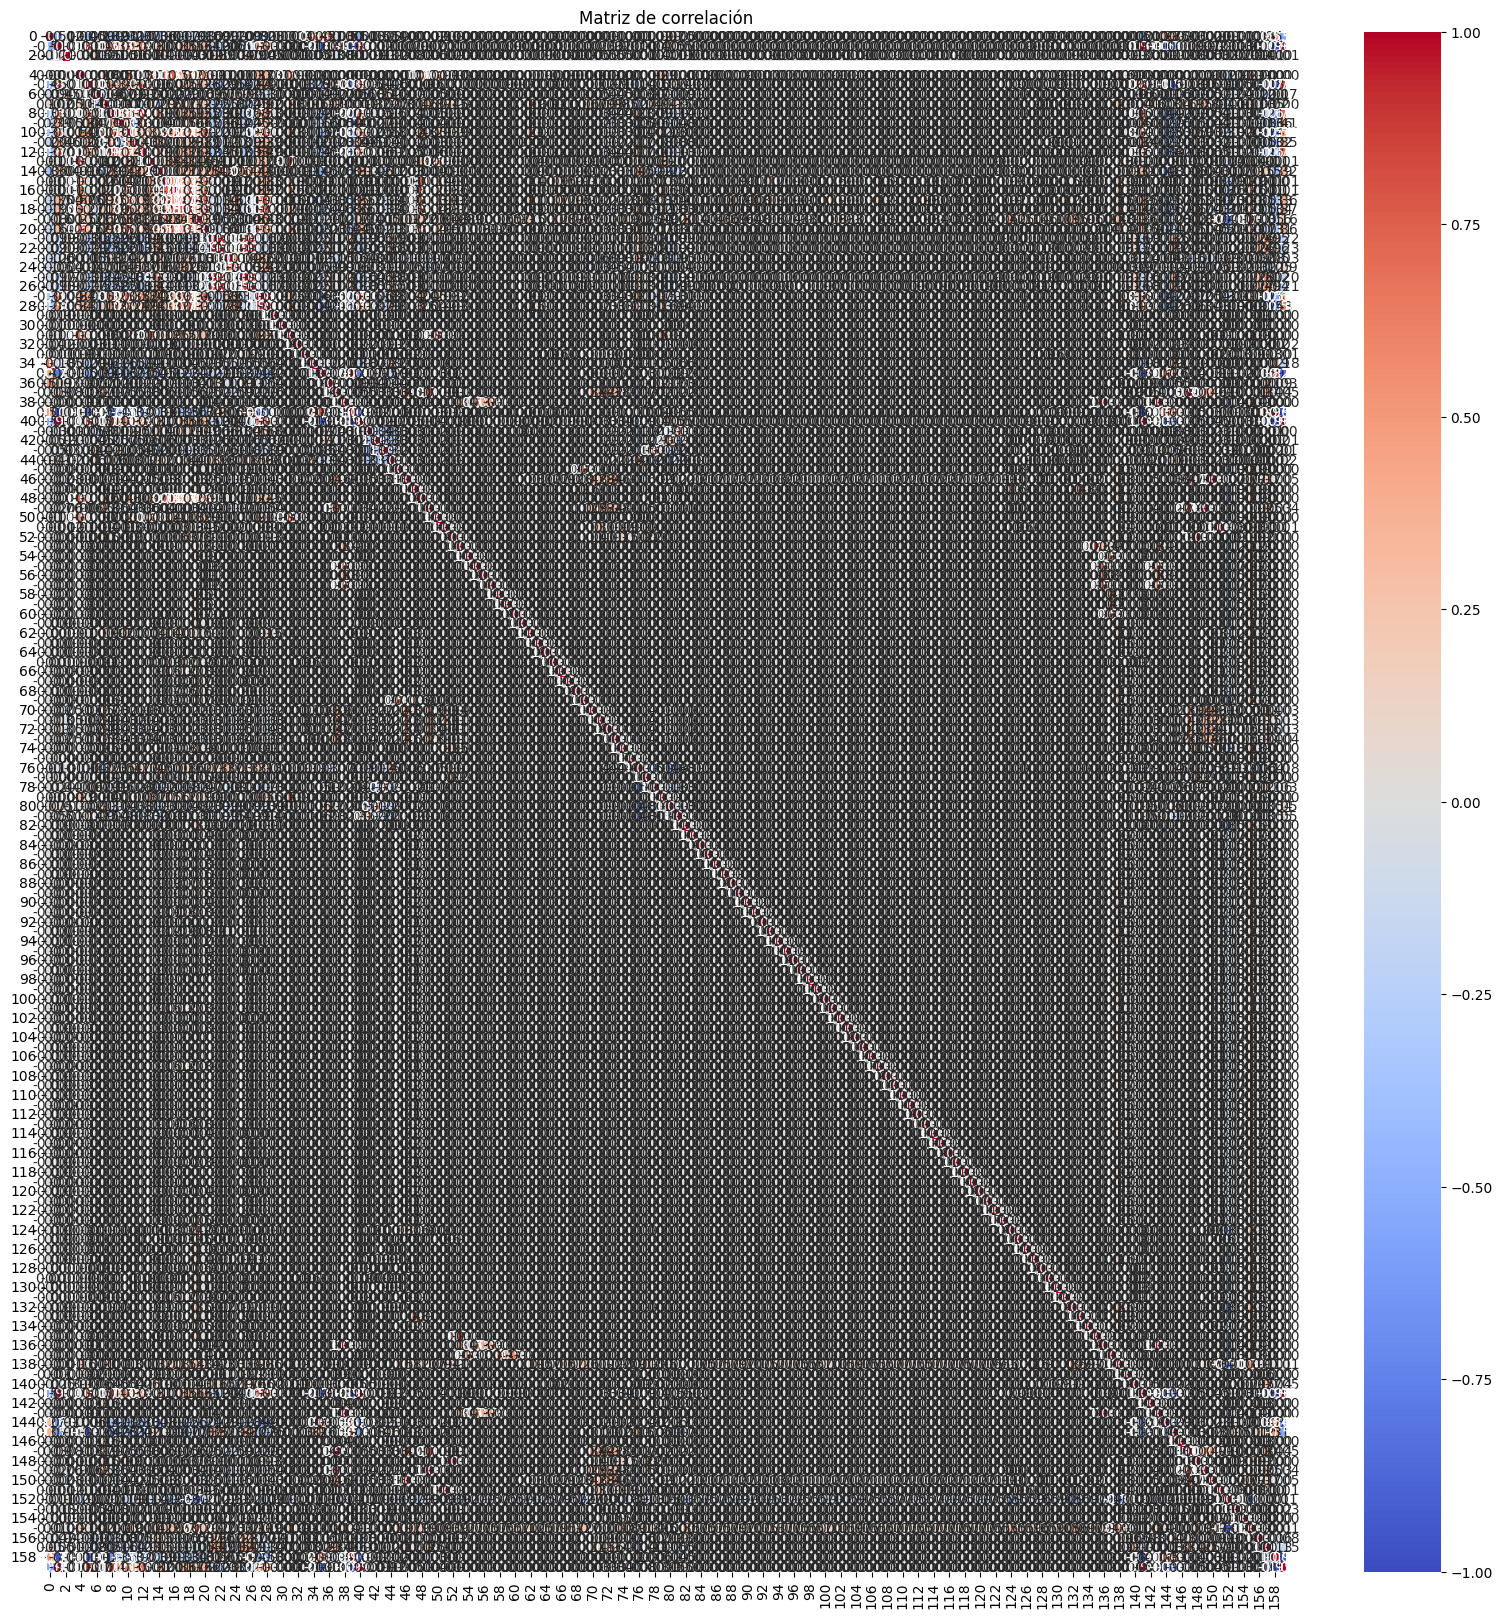

In [44]:
matriz_corr = df_X_train.corr(numeric_only=True)

plt.figure(figsize=(20, 20))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de correlación")
plt.show()

**COMENTARIO**

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Seleccionar columnas numéricas
num_cols = df_X_train.select_dtypes(include=[np.number]).columns

# Convertir a float
X_num = X[num_cols].astype(float)
X_sample = X_num.sample(10000)
# Calcular VIF
vif_data = pd.DataFrame()
vif_data["feature"] = num_cols
vif_data["VIF"] = [round(variance_inflation_factor(X_sample.values, i), 4) for i in range(X_sample.shape[1])]

# Ordenar por VIF descendente
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

KeyError: 'None of [RangeIndex(start=0, stop=160, step=1)] are in the [columns]'

#### Visualización de las variables:

#### Principales métricas:

## Modelo Autoencoder+MLP:

In [45]:
import tensorflow as tf
import keras_tuner

#### Definición, compilación y entrenamiento del autoencoder:

<!-- #### Definición y compilación del autoencoder: -->

In [54]:
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)


def creacion_autoencoder(hp):
    input_dim = X_train_processed.shape[1]

    # Hiperparámetro
    activacion = hp.Choice('activation', ['relu', 'tanh'])
    tasa_aprendizaje = hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])
    
    # Definición de capas, usadas en el encoder y decoder
    units1 = hp.Int('units1', 32, 128, step=32)
    units2 = hp.Int('units2', 16, 64, step=16)
    latent_dim = hp.Int('latent_dim', 4, 32, step=4)
    
    # Regularización L2 como hiperparámetro
    l2_strength = hp.Choice('l2_strength', [1e-5, 1e-4, 1e-3])

    # Encoder
    encoder = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(units1, activation=activacion,
            kernel_regularizer=keras.regularizers.l2(l2_strength)),
        layers.Dropout(0.2),
        layers.Dense(units2, activation=activacion,
                     kernel_regularizer=keras.regularizers.l2(l2_strength)),
        layers.Dropout(0.2),
        layers.Dense(latent_dim, activation='linear'),
    ])

    # Decoder
    decoder = keras.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(units2, activation=activacion,
                    kernel_regularizer=keras.regularizers.l2(l2_strength)),
        layers.Dropout(0.2),
        layers.Dense(units1, activation=activacion,
                    kernel_regularizer=keras.regularizers.l2(l2_strength)),
        layers.Dropout(0.2),
        layers.Dense(input_dim, activation='sigmoid'),
    ])

    autoencoder = keras.Sequential([encoder, decoder])

    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=tasa_aprendizaje),
        loss='mse'
    )
    return autoencoder

In [55]:
import keras_tuner as kt

tuner = kt.RandomSearch(
    creacion_autoencoder,
    objective='val_loss',
    max_trials=10,
    directory='C:/Users/Usuario/keras_tuner_runs',
    project_name='autoencoder_1',
    seed=42
)

tuner.search(
    X_train_processed,
    X_train_processed,
    validation_data=(X_val_processed, X_val_processed),
    epochs=20,
    batch_size=256,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,  # Por si val_loss no mejora en 5 épocas
            restore_best_weights=True
    )]
)

Trial 10 Complete [00h 16m 02s]
val_loss: 0.003950899001210928

Best val_loss So Far: 0.0006611833232454956
Total elapsed time: 04h 00m 19s


In [ ]:
# Obtener el mejor modelo
best_model = tuner.get_best_models(num_models=1)[0]

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [61]:
# Extraer encoder
encoder = best_model.layers[0]
encoder.save("encoder.keras")

# Obtener representación latente
X_train_latente = encoder.predict(X_train_processed)
X_val_latente = encoder.predict(X_val_processed)


np.save("X_train_latent.npy", X_train_latente)
np.save("X_val_latent.npy", X_val_latente)
np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)

91714/91714 ━━━━━━━━━━━━━━━━━━━━ 145s 2ms/step
22929/22929 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step


In [ ]:

"""
==============================================================================
PARTE 1: VISUALIZAR EL MEJOR MODELO
==============================================================================
"""
print("="*80)
print("INFORMACIÓN DEL MEJOR MODELO")
print("="*80)
best_model.summary()
 
print("\n" + "="*80)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS")
print("="*80)
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
for param, value in best_hyperparameters.values.items():
    print(f"  {param}: {value}")
 
 
"""
==============================================================================
PARTE 2: PREDICCIONES Y CÁLCULO DE MÉTRICAS (CRÍTICO)
==============================================================================
"""
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
 
# Hacer predicciones
y_train_pred = best_model.predict(X_train_processed, verbose=0)
y_val_pred = best_model.predict(X_val_processed, verbose=0)
 
# Calcular métricas
def calcular_metricas(y_true, y_pred, nombre_set=""):
    """Calcula todas las métricas relevantes"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    errors = np.abs(y_true - y_pred)
    
    result = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'Mean_Error': np.mean(errors),
        'Std_Error': np.std(errors),
        'Median_Error': np.median(errors),
        'P95_Error': np.percentile(errors, 95),
        'P99_Error': np.percentile(errors, 99),
        'Max_Error': np.max(errors),
    }
    return result


INFORMACIÓN DEL MEJOR MODELO


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32)             │        21,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 160)            │        21,808 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,488 (169.88 KB)

 Trainable params: 43,488 (169.88 KB)

 Non-trainable params: 0 (0.00 B)


MEJORES HIPERPARÁMETROS ENCONTRADOS
  activation: relu
  learning_rate: 0.001
  units1: 96
  units2: 48
  latent_dim: 32
  l2_strength: 1e-05


In [ ]:
 
metricas_train = calcular_metricas(X_train_processed, y_train_pred, "TRAIN")
metricas_val = calcular_metricas(X_val_processed, y_val_pred, "VALIDATION")

# Imprimir resultados
print("\n" + "="*80)
print("MÉTRICAS DE VALIDACIÓN - DETALLADAS")
print("="*80)
print("\nTRAINING SET:")
for metric, value in metricas_train.items():
    print(f"  {metric:15s}: {value:.8f}")
 
print("\nVALIDATION SET:")
for metric, value in metricas_val.items():
    print(f"  {metric:15s}: {value:.8f}")


MÉTRICAS DE VALIDACIÓN - DETALLADAS

TRAINING SET:
  MAE            : 0.00322607
  MSE            : 0.00036597
  RMSE           : 0.01913023
  Mean_Error     : 0.00322607
  Std_Error      : 0.01885625
  Median_Error   : 0.00000147
  P95_Error      : 0.01292731
  P99_Error      : 0.08382432
  Max_Error      : 1.00000000

VALIDATION SET:
  MAE            : 0.00322323
  MSE            : 0.00036604
  RMSE           : 0.01913225
  Mean_Error     : 0.00322323
  Std_Error      : 0.01885878
  Median_Error   : 0.00000146
  P95_Error      : 0.01289383
  P99_Error      : 0.08374447
  Max_Error      : 1.00000000


In [66]:
# Diagnosticar overfitting
gap = metricas_val['MSE'] - metricas_train['MSE']
print("\n" + "-"*80)
if gap > 0.0001:
    print(f"OVERFITTING DETECTADO (Gap: {gap:.2e})")
elif gap > 0:
    print(f"Ligero overfitting normal (Gap: {gap:.2e})")
else:
    print(f"EXCELENTE: Val mejor que Train (Gap: {gap:.2e})")
 
 
"""
==============================================================================
PARTE 3: COMPARAR CON BASELINE (CRÍTICO)
==============================================================================
"""
print("\n" + "="*80)
print("COMPARACIÓN CON BASELINE")
print("="*80)
 
# Baseline: predicción de la media
baseline_train = np.mean(X_train_processed, axis=0)
baseline_train_mse = np.mean((X_train_processed - baseline_train)**2)
baseline_val_mse = np.mean((X_val_processed - baseline_train)**2)
 
model_train_mse = metricas_train['MSE']
model_val_mse = metricas_val['MSE']
 
improvement_train = (1 - model_train_mse / baseline_train_mse) * 100
improvement_val = (1 - model_val_mse / baseline_val_mse) * 100
 
print("\nBASELINE (predicción de media):")
print(f"Training MSE:  {baseline_train_mse:.8f}")
print(f"Validation MSE: {baseline_val_mse:.8f}")
 
print("\nAUTOENCODER:")
print(f"Training MSE:  {model_train_mse:.8f}  ({improvement_train:+.2f}%)")
print(f"Validation MSE: {model_val_mse:.8f}  ({improvement_val:+.2f}%)")
 
print("\n" + "-"*80)
if improvement_val > 50:
    print(f"EXCELENTE: Mejora {improvement_val:.1f}% vs baseline")
elif improvement_val > 0:
    print(f"ACEPTABLE: Mejora {improvement_val:.1f}% vs baseline")
else:
    print("PROBLEMA: El modelo es PEOR que baseline")
print("-"*80)


--------------------------------------------------------------------------------
Ligero overfitting normal (Gap: 7.73e-08)

COMPARACIÓN CON BASELINE

BASELINE (predicción de media):
Training MSE:  0.02671101
Validation MSE: 0.02669434

AUTOENCODER:
Training MSE:  0.00036597  (+98.63%)
Validation MSE: 0.00036604  (+98.63%)

--------------------------------------------------------------------------------
EXCELENTE: Mejora 98.6% vs baseline
--------------------------------------------------------------------------------


El autoencoder presenta una generalización excelente con un **gap de overfitting de 7.73e-08**, prácticamente despreciable. La mejora del $98.63\%$ respecto al baseline evidencia que el modelo ha aprendido representaciones significativas en lugar de memorizar. La **consistencia entre métricas de train y validación** ($MSE$: 0.00036597 vs 0.00036604) valida la efectividad de la regularización L2 y el dropout en prevenir overfitting. El MAE de 0.0032 indica una reconstrucción muy precisa. La única limitación conocida es el `Max_Error=1.0` en aproximadamente el $1\%$ de muestras, atribuible a la activación sigmoid en valores extremos, pero no impacta significativamente el uso del encoder para extracción de features latentes.